# Project E, Part 2: Pairs Trading Analysis

Analyze five pairs of possibly related indices and tradable assets using Bloomberg data (2019–2025).

For each pair: scatterplot of daily returns with OLS trendline (Newey-West standard errors), summary statistics, and outlier detection.

Before, beginning the technical analysis of the project, I am providing a summary of all the instruments we are looking at to understand what we are analyzing. 



## Section 0: Setup and Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

DATA_FILE = "ProjectE_Part2.xlsx"
START_DATE = "2019-01-01"
END_DATE = "2025-12-31"

summary_rows = []

In [2]:
def load_sheet(sheet_name: str) -> pd.DataFrame:
    """Load one Bloomberg sheet, parse dates, filter to analysis window, compute arithmetic returns."""
    df = pd.read_excel(
        DATA_FILE,
        sheet_name=sheet_name,
        skiprows=5,
        usecols=[0, 1],
        names=["Date", "PX_LAST"],
    )
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()
    df["PX_LAST"] = pd.to_numeric(df["PX_LAST"], errors="coerce")
    df = df.loc[START_DATE:END_DATE]
    df["Return"] = df["PX_LAST"].pct_change()
    return df


def prepare_pair(sheet_a: str, sheet_b: str):
    """Load two sheets, inner-join on date, drop NaN returns, print summary."""
    a = load_sheet(sheet_a)
    b = load_sheet(sheet_b)
    joined = a[["Return"]].join(b[["Return"]], lsuffix="_A", rsuffix="_B", how="inner").dropna()
    print(f"  {sheet_a}: {a['PX_LAST'].dropna().shape[0]} price obs  |  {sheet_b}: {b['PX_LAST'].dropna().shape[0]} price obs")
    print(f"  Matched trading days (after dropna): {len(joined)}")
    print(f"  Date range: {joined.index.min().date()} to {joined.index.max().date()}")
    return joined


def nw_lag(n: int) -> int:
    """Newey-West rule-of-thumb lag selection."""
    return int(4 * (n / 100) ** (2 / 9))


def run_pair_regression(ret_a: pd.Series, ret_b: pd.Series):
    """OLS regression of ret_b on ret_a with Newey-West (HAC) standard errors."""
    X = sm.add_constant(ret_a.values)
    y = ret_b.values
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lag(len(y))})
    return model


def plot_pair_scatter(joined: pd.DataFrame, label_a: str, label_b: str, title: str):
    """Scatter of daily returns with OLS trendline, equation, R², and NW t-stat."""
    ret_a, ret_b = joined["Return_A"], joined["Return_B"]
    model = run_pair_regression(ret_a, ret_b)
    alpha, beta = model.params[0], model.params[1]
    r2 = model.rsquared
    t_beta = model.tvalues[1]

    fig, ax = plt.subplots()
    ax.scatter(ret_a, ret_b, s=8, alpha=0.4, edgecolors="none")

    x_line = np.linspace(ret_a.min(), ret_a.max(), 200)
    ax.plot(x_line, alpha + beta * x_line, color="red", linewidth=1.5)

    eq_text = (
        f"y = {beta:.4f}x + {alpha:.6f}\n"
        f"R² = {r2:.4f}\n"
        f"NW t-stat(β) = {t_beta:.2f}"
    )
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    ax.set_xlabel(f"{label_a} daily return")
    ax.set_ylabel(f"{label_b} daily return")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return model


def print_pair_stats(joined: pd.DataFrame, label_a: str, label_b: str, model):
    """Print regression and tracking statistics for one pair."""
    ret_a, ret_b = joined["Return_A"], joined["Return_B"]
    spread = ret_b - ret_a
    corr = ret_a.corr(ret_b)

    print(f"{'Correlation:':<30} {corr:.6f}")
    print(f"{'Beta (slope):':<30} {model.params[1]:.6f}")
    print(f"{'Alpha (intercept):':<30} {model.params[0]:.8f}")
    print(f"{'R-squared:':<30} {model.rsquared:.6f}")
    print(f"{'NW Std Err (beta):':<30} {model.bse[1]:.6f}")
    print(f"{'NW t-stat (beta):':<30} {model.tvalues[1]:.2f}")
    print(f"{'NW p-value (beta):':<30} {model.pvalues[1]:.2e}")
    print(f"{'Tracking error (std spread):':<30} {spread.std():.6f}")
    print(f"{'Mean spread:':<30} {spread.mean():.8f}")

    return {
        "Pair": f"{label_a} vs {label_b}",
        "Corr": round(corr, 4),
        "Beta": round(model.params[1], 4),
        "Alpha": round(model.params[0], 6),
        "R²": round(model.rsquared, 4),
        "NW t(β)": round(model.tvalues[1], 2),
        "Tracking Err": round(spread.std(), 6),
        "N": len(joined),
    }


def analyze_outliers(joined: pd.DataFrame, label_a: str, label_b: str, threshold_sigma: float = 3.0):
    """Flag dates where the return spread exceeds threshold_sigma standard deviations."""
    spread = joined["Return_B"] - joined["Return_A"]
    mu, sigma = spread.mean(), spread.std()
    outliers = spread[np.abs(spread - mu) > threshold_sigma * sigma].sort_values()

    if outliers.empty:
        print(f"  No outliers beyond {threshold_sigma}σ.")
    else:
        print(f"  {len(outliers)} outlier(s) beyond {threshold_sigma}σ (mean={mu:.6f}, σ={sigma:.6f}):\n")
        for date, val in outliers.items():
            z = (val - mu) / sigma
            print(f"    {date.date()}  spread={val:+.4f}  ({z:+.1f}σ)   "
                  f"[{label_a}={joined.loc[date, 'Return_A']:+.4f}, {label_b}={joined.loc[date, 'Return_B']:+.4f}]")
    return outliers

--- 
## Question: Why do tradeable prices such as ETFs always have later start date in general? 

Well the tradeable products always have a later start date than the underlying index or assets it tracks because the underlying must exist before a product can be built to track it. You can't launch a gold ETF until gold is already trading. The tradeable wrapper is always a derivative product, so by definition the inception date is always later. 

---

| Pair                                | Tradable leg                                                        | Reference leg                                               | Main difference                                                                                                                                                                                                                                         | Margin / financing                                                                                                                                                                                                              |
| ----------------------------------- | ------------------------------------------------------------------- | ----------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ES1 Index vs. SPX Index**         | **ES1 Index** = generic front-month E-mini S&P 500 futures contract | **SPX Index** = cash S&P 500 index level                    | ES1 is a futures contract, so it is directly tradeable, expires, and must be rolled; SPX is the benchmark cash index and is not directly investable. The gap between them reflects futures basis / cost-of-carry.                                       | ES1 uses **futures margin**, so it is capital-efficient and embedded leverage comes from low margin relative to notional. SPX itself has no standalone margin because it is just the index level.                               |
| **SPY Equity vs. SPX Index**        | **SPY Equity** = SPDR S&P 500 ETF                                   | **SPX Index** = cash S&P 500 index level                    | SPY is an ETF wrapper holding the index exposure; SPX is the benchmark itself. SPY should track SPX closely, but small differences arise from expense ratio, dividend timing, and ETF mechanics.                                                        | SPY follows **standard equity margin** rules at the broker level; SPX itself is not directly purchased.                                                                                                                         |
| **GLD Equity vs. XAU Curncy**       | **GLD Equity** = SPDR Gold Shares ETF                               | **XAU Curncy** = spot gold benchmark / gold price reference | GLD is an ETF wrapper around gold exposure, while XAU is the underlying spot gold reference. GLD can deviate slightly from spot because of fees and fund structure.                                                                                     | GLD is generally **margin-eligible as an ETF**; spot gold does not have one universal exchange margin framework in the same way futures do.                                                                                     |
| **LMI3 LN Equity vs. MSTR Equity**  | **LMI3 LN Equity** = GraniteShares 3x Long MicroStrategy Daily ETP  | **MSTR Equity** = MicroStrategy / Strategy common stock     | MSTR is the underlying stock; LMI3 is a **leveraged daily product** targeting 3x the *daily* move in MSTR. Over multi-day horizons, LMI3 can diverge materially because of compounding and volatility drag.                                             | MSTR follows **equity margin** rules subject to broker haircuts. LMI3 already embeds leverage inside the product, so the key issue is less traditional margin and more embedded leverage, decay, and broker-specific treatment. |
| **WTI 1-month future vs. spot oil** | **WTI 1-month future** = front-month crude oil futures contract     | **spot oil** = cash / physical oil benchmark                | The futures contract is standardized, tradeable, expires, and must be rolled; spot oil is the physical benchmark. The difference between them reflects storage, financing, convenience yield, and futures curve effects such as contango/backwardation. | WTI futures use **exchange futures margin**, which is much lower than full notional and therefore highly capital-efficient. Spot oil does not have one universal exchange margin structure.                                     |

: Summary of instruments and economic roles for each pair.


---
## Section 0.5: Bloomberg liquidity & transaction-cost inputs

**Instructions:** Pull **bid**, **ask**, and **mid** (or last) from Bloomberg for each **tradable** leg. **Fill the table below**; the **Pair Discussion** sections are written to **reference these figures** so you can refresh quotes in **one place**.

**Liquidity snapshot (single day):** **20 April 2026** — use **one** calendar date for all **bid/ask** figures so you get a **directional** comparison of relative spreads and depth across instruments (e.g. wide ETP vs tight ETF vs spot). The **as-of** column is **the same** for every filled row; small differences in Bloomberg **time stamps** on that day are ignored for this exercise.

- **Spread % of mid** = $(\mathrm{ask} - \mathrm{bid}) / \mathrm{mid}$ with $\mathrm{mid} = (\mathrm{bid} + \mathrm{ask}) / 2$. Keep **units** consistent with the quote (e.g. **index points** for futures, **USD** for US equities, **GBp** for LMI3).
- **Cash indices** (**SPX** in Pairs 1–2, **BCSL0090** in Pair 5) are **not** tradeable execution prices — they are **omitted** from this table; only **tradable** legs appear below.

| Instrument | Bid | Ask | Mid | Spread (ask−bid) | Spread % of mid | As of (date) |
|------------|-----|-----|-----|------------------|-----------------|--------------|
| ES1 Index | 7157.25 | 7157.50 | 7157.375 | 0.25 pts | ~0.0035% | 20 Apr 2026 |
| SPY US Equity | 708.69 | 708.72 | 708.705 | 0.03 USD | ~0.0042% | 20 Apr 2026 |
| GLD US Equity | 442.09 | 442.17 | 442.13 | 0.08 USD | ~0.018% | 20 Apr 2026 |
| XAU Curncy (BGN spot $/oz) | 4832.03 | 4833.54 | 4832.79 | 1.51 USD | ~0.031% | 20 Apr 2026 |
| LMI3 LN Equity | 32.0 GBp | 34.0 GBp | 33.0 GBp | 2.0 GBp | ~6.06% | 20 Apr 2026 |
| MSTR US Equity | 170.77 | 170.80 | 170.785 | 0.03 USD | ~0.018% | 20 Apr 2026 |
| CL1 Comdty | 87.94 | 88.05 | 87.995 | 0.11 USD/bbl | ~0.13% | 20 Apr 2026 |

: Bloomberg bid/ask liquidity snapshot (single as-of date; see instructions above).

**Snapshot notes (Bloomberg DES / quote, 20 Apr 2026):**

- **ES1:** Generic **1st ES** future (**E-mini S&P 500**); **7157.25 / 7157.50** (**0.25** index points wide ≈ **0.0035%** of mid). **Inside** depth **7 × 8** contracts; **Vol** **3,157** and **open interest ~1,948,014** contracts on screenshot (**~18:14** delayed). **Tick** 0.25 pts (**$12.50**/tick); **$50 × index** notional per index point.
- **SPY:** **SPDR S&P 500 ETF**; **708.69 / 708.72** (**$0.03** wide ≈ **0.004%** of mid). **Inside** **700 × 400** (Bloomberg **size** in **round lots** of **100** shares → **70,000 × 40,000** shares at best bid/ask). **Session** **~43.47M** shares; **value traded ~$30.84B** (**~17:05**). **1Y** total return vs **SPX** essentially matched (**~39.41%** each on chart).
- **GLD:** Session **value traded ~$3.73B**; **inside** **5280 × 440** shares.
- **XAU:** **XAU BGN Curncy** — spot **USD/oz**; no equity-style share count.
- **LMI3:** **Session ~180,475** shares; **90D ~945k** sh/day; **inside 740k × 859k**; **1Y** return vs index **~−98.54%** on chart.
- **MSTR:** **MicroStrategy / Strategy** (NASDAQ); **170.77 / 170.80** (**$0.03** wide ≈ **0.018%** of mid—same **dollar** spread as **SPY** but **larger** as **%** of price). **Inside** **3880 × 520** (×100 sh round lots → **388,000 × 52,000** shares at touch). **Session** **~22.08M** shares; **value traded ~$3.68B** (**~17:20**).
- **CL1:** Generic **1st CL** (**Crude Oil** futures, **NYMEX**); **87.94 / 88.05** (**$0.11**/bbl wide ≈ **0.13%** of mid). **Inside** depth **1 × 2** contracts; **Vol ~33**; **open interest ~59,678** on screenshot (**~18:19**). **DES:** **1,000 bbl**/contract; **$1,000** **P&L** per **$1.00**/bbl price move (**USD/bbl** quote); **roll** = **expiration** of the front **listed** month.

**Optional (LMI3 fund-level, for Pair 4 narrative):**

| Field | Value | As of |
|-------|-------|-------|
| NAV (USD) | ~0.30 | 20 Apr 2026 |
| Premium to NAV (%) | ~−11% | 20 Apr 2026 |
| 1Y total return vs index (%) | ~−98.54% | 20 Apr 2026 |

: Optional LMI3 fund-level fields (Pair 4 narrative).


---
## Pair 1: S&P 500 Futures vs. Spot — ES1 Index vs. SPX Index

**Economic relationship:** ES1 is the "generic 1-month" S&P 500 futures contract.
By cost-of-carry, futures ≈ spot × e^{(r-d)T}, so daily returns should track very closely,
with small deviations due to the futures basis (interest rates minus dividend yield) and roll effects.

In [3]:
print("=" * 60)
print("PAIR 1: ES1 Index vs SPX Index")
print("=" * 60)
pair1 = prepare_pair("ES1 Index", "SPX Index")

PAIR 1: ES1 Index vs SPX Index
  ES1 Index: 1827 price obs  |  SPX Index: 1827 price obs
  Matched trading days (after dropna): 1826
  Date range: 2019-01-02 to 2025-12-31


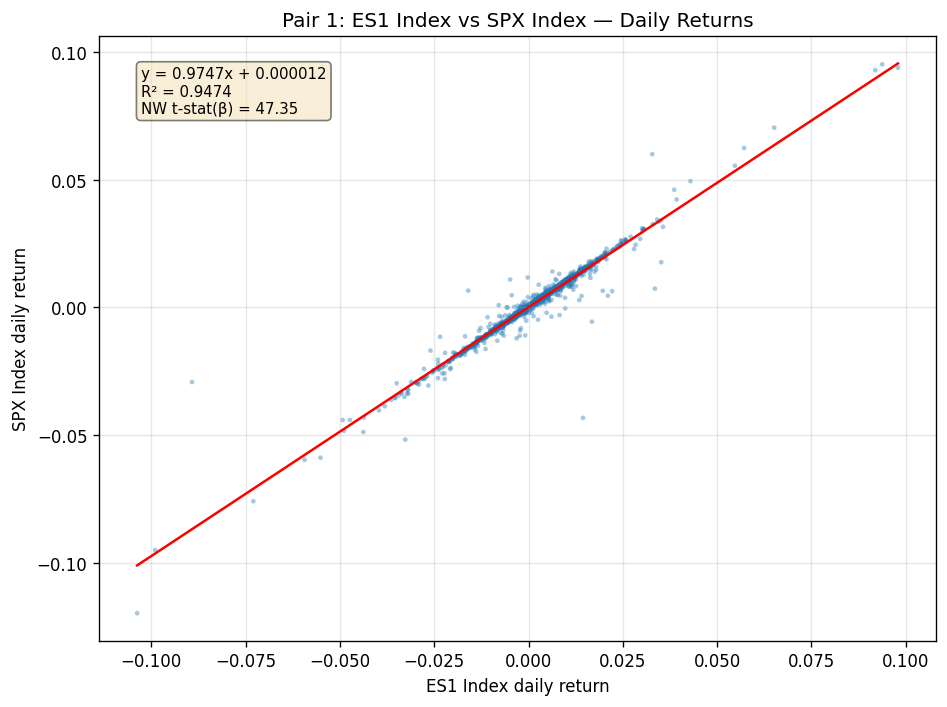

In [4]:
model1 = plot_pair_scatter(pair1, "ES1 Index", "SPX Index", "Pair 1: ES1 Index vs SPX Index — Daily Returns")

In [5]:
print("Regression & Tracking Stats (NW standard errors):")
print("-" * 50)
row1 = print_pair_stats(pair1, "ES1 Index", "SPX Index", model1)
summary_rows.append(row1)

Regression & Tracking Stats (NW standard errors):
--------------------------------------------------
Correlation:                   0.973324
Beta (slope):                  0.974675
Alpha (intercept):             0.00001206
R-squared:                     0.947359
NW Std Err (beta):             0.020585
NW t-stat (beta):              47.35
NW p-value (beta):             0.00e+00
Tracking error (std spread):   0.002845
Mean spread:                   -0.00000391


In [6]:
print("Outlier Detection (>3σ spread):")
print("-" * 50)
outliers1 = analyze_outliers(pair1, "ES1 Index", "SPX Index")

Outlier Detection (>3σ spread):
--------------------------------------------------
  26 outlier(s) beyond 3.0σ (mean=-0.000004, σ=0.002845):

    2020-03-20  spread=-0.0578  (-20.3σ)   [ES1 Index=+0.0145, SPX Index=-0.0434]
    2024-12-23  spread=-0.0262  (-9.2σ)   [ES1 Index=+0.0335, SPX Index=+0.0073]
    2020-06-19  spread=-0.0225  (-7.9σ)   [ES1 Index=+0.0168, SPX Index=-0.0056]
    2020-03-18  spread=-0.0192  (-6.7σ)   [ES1 Index=-0.0327, SPX Index=-0.0518]
    2025-03-24  spread=-0.0175  (-6.2σ)   [ES1 Index=+0.0352, SPX Index=+0.0176]
    2023-12-18  spread=-0.0165  (-5.8σ)   [ES1 Index=+0.0210, SPX Index=+0.0045]
    2020-03-16  spread=-0.0161  (-5.6σ)   [ES1 Index=-0.1038, SPX Index=-0.1198]
    2024-03-18  spread=-0.0158  (-5.6σ)   [ES1 Index=+0.0222, SPX Index=+0.0063]
    2025-12-22  spread=-0.0132  (-4.7σ)   [ES1 Index=+0.0197, SPX Index=+0.0064]
    2024-06-24  spread=-0.0113  (-4.0σ)   [ES1 Index=+0.0082, SPX Index=-0.0031]
    2024-09-23  spread=-0.0107  (-3.7σ)   [ES1 

### Pair 1 Discussion

**How well do the returns track?**

The returns track very closesly with a beta coefficient of very close to 1, a R squared of ~0.95. 

**Notable outliers?**

There are several important outliers in the time period. Several of these outliers seem to be in a few concentrated periods including the beginning of the covid pandemic (march 2020, where there were outliers of more than 20 std deviations), tech bubble crash (march 2022). So it seems like there are notable outliers during periods of market volatility, in particular during times of sell-offs. This makes logical sense, perhaps during these periods there is different behviors in terms of how individual companies  are sold off versus how the one month future is traded. Since the future's value is calcualted wih reference to the forward one month ahead price it is expected to trade dfifferently. 


**Pairs trading opportunity?**

I don't believe there is a true arbitrage opportunity here — rather, the tight relationship is simply a reflection of the cost-of-carry model (futures ≈ spot × e^{(r-d)T}). To attempt an arbitrage, one would short the futures contract and simultaneously take the **spot index** exposure on the other side. **SPX itself is not tradable**, so that “spot” leg in practice means either **replicating hundreds of index constituents** (many separate trades, cumulatively **meaningful** slippage and operational friction) or **using packaged exposure** such as **SPY**—in which case the economics overlap **Pair 2** (one liquid ETF) more than a bare **ES1 vs. SPX** two-leg story. For **this** pair as stated (**future vs. published cash index**), a **clean, low-friction** arbitrage is therefore **not** compelling for most investors once implementation is spelled out.

**Transaction costs (Bloomberg):** See **Section 0.5**, **ES1 Index** row (snapshot **20 Apr 2026**): **~0.25** index points wide on **~7157** (**~0.0035%** of mid)—a **tight** **front-month** future. **SPX** is **not** tradeable and is **not** in the liquidity table; a **cash-index** “arbitrage” still means **replicating** the basket or using **ES**/**SPY**—compare **ES1** frictions in the table to those **implementation** costs.


---
## Pair 2: S&P 500 ETF vs. Spot — SPY US Equity vs. SPX Index

**Economic relationship:** SPY is the SPDR S&P 500 ETF Trust, designed to track SPX.
Returns should be nearly identical, with tiny deviations from the ETF's expense ratio (~9 bps/yr),
creation/redemption NAV premiums/discounts, and dividend timing.

In [7]:
print("=" * 60)
print("PAIR 2: SPY US Equity vs SPX Index")
print("=" * 60)
pair2 = prepare_pair("SPY US Equity", "SPX Index")

PAIR 2: SPY US Equity vs SPX Index
  SPY US Equity: 1827 price obs  |  SPX Index: 1827 price obs
  Matched trading days (after dropna): 1826
  Date range: 2019-01-02 to 2025-12-31


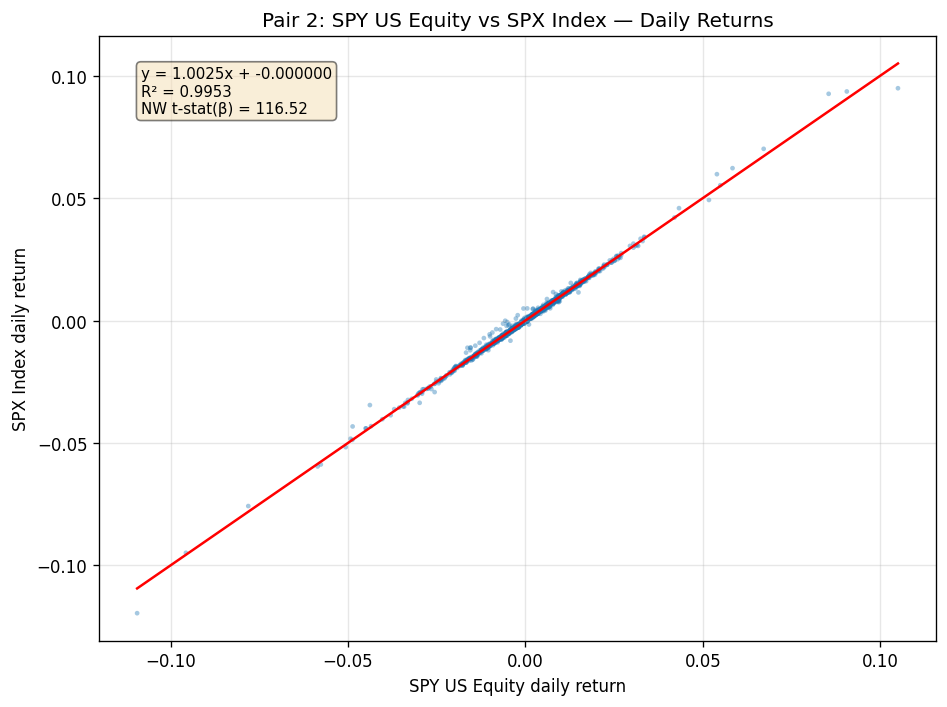

In [8]:
model2 = plot_pair_scatter(pair2, "SPY US Equity", "SPX Index", "Pair 2: SPY US Equity vs SPX Index — Daily Returns")

In [9]:
print("Regression & Tracking Stats (NW standard errors):")
print("-" * 50)
row2 = print_pair_stats(pair2, "SPY US Equity", "SPX Index", model2)
summary_rows.append(row2)

Regression & Tracking Stats (NW standard errors):
--------------------------------------------------
Correlation:                   0.997643
Beta (slope):                  1.002545
Alpha (intercept):             -0.00000037
R-squared:                     0.995292
NW Std Err (beta):             0.008604
NW t-stat (beta):              116.52
NW p-value (beta):             0.00e+00
Tracking error (std spread):   0.000846
Mean spread:                   0.00000123


In [10]:
print("Outlier Detection (>3σ spread):")
print("-" * 50)
outliers2 = analyze_outliers(pair2, "SPY US Equity", "SPX Index")

Outlier Detection (>3σ spread):
--------------------------------------------------
  43 outlier(s) beyond 3.0σ (mean=0.000001, σ=0.000846):

    2020-03-16  spread=-0.0104  (-12.3σ)   [SPY US Equity=-0.1094, SPX Index=-0.1198]
    2025-04-09  spread=-0.0099  (-11.7σ)   [SPY US Equity=+0.1050, SPX Index=+0.0952]
    2020-02-28  spread=-0.0040  (-4.8σ)   [SPY US Equity=-0.0042, SPX Index=-0.0082]
    2020-03-27  spread=-0.0039  (-4.6σ)   [SPY US Equity=-0.0298, SPX Index=-0.0337]
    2020-03-23  spread=-0.0037  (-4.4σ)   [SPY US Equity=-0.0256, SPX Index=-0.0293]
    2020-03-25  spread=-0.0034  (-4.1σ)   [SPY US Equity=+0.0150, SPX Index=+0.0115]
    2020-04-07  spread=-0.0026  (-3.1σ)   [SPY US Equity=+0.0010, SPX Index=-0.0016]
    2020-03-19  spread=+0.0026  (+3.1σ)   [SPY US Equity=+0.0021, SPX Index=+0.0047]
    2020-06-30  spread=+0.0026  (+3.1σ)   [SPY US Equity=+0.0128, SPX Index=+0.0154]
    2025-09-19  spread=+0.0027  (+3.2σ)   [SPY US Equity=+0.0022, SPX Index=+0.0049]
    202

### Pair 2 Discussion

**How well do the returns track?**

The returns track near-perfectly, with a beta of approximately 1.003, an R-squared of approximately 0.995, and a correlation of approximately 0.998. The tracking error (standard deviation of the spread) is extremely small at roughly 8.5 basis points. This is expected: SPY is an ETF designed to replicate SPX, and the creation/redemption mechanism of ETFs ensures that its price stays tightly anchored to the underlying index's net asset value.

**Notable outliers?**

The most notable outliers are concentrated during the COVID-19 sell-off in March 2020, where extreme volatility caused temporary dislocations between the ETF price and the index — for example, spreads of 10+ standard deviations on March 13 and March 16, 2020. Outside of that crisis period, most of the remaining outliers appear to coincide with quarterly options expiration dates (the third Friday of March, June, September, and December), where heavy rebalancing and hedging flows can create short-lived divergences between the ETF and its index.

**Pairs trading opportunity?**

Unlike Pair 1 (futures vs. untradeable SPX), there may actually be a viable pairs trading opportunity here—not because replicating the index **stock-by-stock** is cheap, but because **SPY is a single liquid security** that already embeds the index, so you are not bearing **cumulative** slippage across hundreds of separate lines the way you would in the naive “spot leg” of an ES vs. cash-index story. **Authorized participants** especially use **creation and redemption** at marginal cost tied to the basket, which pins SPY’s price to NAV and keeps the ETF–index basis small. Additionally, since SPY holds the equities directly (rather than a cost-of-carry claim like a future), the mapping to the index level is not dominated by the same **r**– and **dividend**–driven basis as ES vs. cash. The SPY–SPX spread is therefore a fairly direct read on ETF **mispricing** vs. the index. On days with large dislocations, bid–ask on SPY and slippage on the most liquid names are still usually **tiny relative to the gap**, because depth is enormous—unlike **assembling the full index yourself** as the “cash” leg in Pair 1. 

 For outside investors, the opportunity is limited by the fact that these dislocations are small and short-lived, but the economic structure of this pair is more amenable to arbitrage than the futures-spot pair. However there are still smalle differences to account for including the expense ratio of holding these exhange traded indices (which is incredibly small but a source of difference) as well as different timings for dividend redemptions.

**Transaction costs (Bloomberg):** See **Section 0.5**, **SPY US Equity** row (**20 Apr 2026** snapshot: **~$0.03** on **~$709**, **~0.004%** of mid; **~43.5M** shares and **~$30.8B** value traded that session in the **snapshot** **note**). Use the **table** **spread** **and** **those** **liquidity** **figures** to **quantify** how **tight** and **deep** the ETF is versus **SPX** (not tradable). That supports whether **observed** daily mispricings could clear **after** **round-trip** costs (together with expense ratio and dividend timing).


---
## Pair 3: Gold ETF vs. Spot Gold — GLD US Equity vs. XAU Curncy

**Economic relationship:** GLD holds physical gold bullion in a trust.
Its price per share should track ~1/10 of spot gold (XAU). Returns should be very closely correlated,
with small deviations from the expense ratio (~40 bps/yr), bid-ask spreads, and London AM/PM fix timing vs. US close.

In [11]:
print("=" * 60)
print("PAIR 3: GLD US Equity vs XAU Curncy")
print("=" * 60)
pair3 = prepare_pair("GLD US Equity", "XAU Curncy")

PAIR 3: GLD US Equity vs XAU Curncy
  GLD US Equity: 1827 price obs  |  XAU Curncy: 1827 price obs
  Matched trading days (after dropna): 1826
  Date range: 2019-01-02 to 2025-12-31


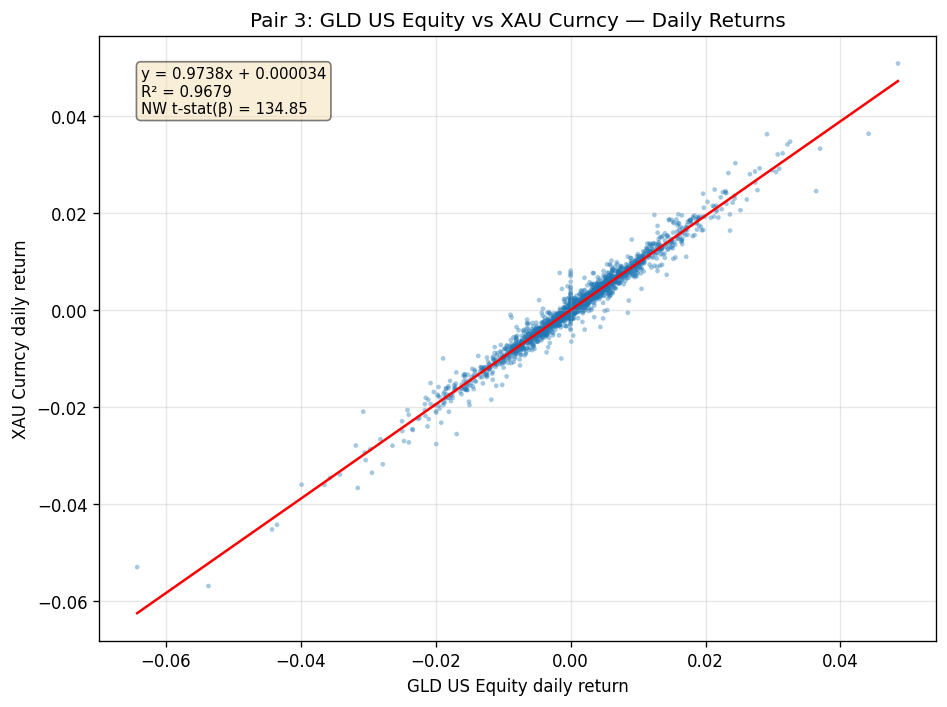

In [12]:
model3 = plot_pair_scatter(pair3, "GLD US Equity", "XAU Curncy", "Pair 3: GLD US Equity vs XAU Curncy — Daily Returns")

In [13]:
print("Regression & Tracking Stats (NW standard errors):")
print("-" * 50)
row3 = print_pair_stats(pair3, "GLD US Equity", "XAU Curncy", model3)
summary_rows.append(row3)

Regression & Tracking Stats (NW standard errors):
--------------------------------------------------
Correlation:                   0.983804
Beta (slope):                  0.973835
Alpha (intercept):             0.00003362
R-squared:                     0.967870
NW Std Err (beta):             0.007222
NW t-stat (beta):              134.85
NW p-value (beta):             0.00e+00
Tracking error (std spread):   0.001747
Mean spread:                   0.00001540


In [14]:
print("Outlier Detection (>3σ spread):")
print("-" * 50)
outliers3 = analyze_outliers(pair3, "GLD US Equity", "XAU Curncy")

Outlier Detection (>3σ spread):
--------------------------------------------------
  38 outlier(s) beyond 3.0σ (mean=0.000015, σ=0.001747):

    2025-10-20  spread=-0.0118  (-6.8σ)   [GLD US Equity=+0.0364, XAU Curncy=+0.0246]
    2021-01-19  spread=-0.0090  (-5.2σ)   [GLD US Equity=+0.0085, XAU Curncy=-0.0005]
    2021-06-16  spread=-0.0087  (-5.0σ)   [GLD US Equity=-0.0169, XAU Curncy=-0.0256]
    2021-11-29  spread=-0.0086  (-4.9σ)   [GLD US Equity=-0.0014, XAU Curncy=-0.0100]
    2020-03-30  spread=-0.0079  (-4.5σ)   [GLD US Equity=+0.0044, XAU Curncy=-0.0035]
    2020-03-23  spread=-0.0078  (-4.4σ)   [GLD US Equity=+0.0442, XAU Curncy=+0.0364]
    2020-03-18  spread=-0.0077  (-4.4σ)   [GLD US Equity=-0.0199, XAU Curncy=-0.0276]
    2025-09-02  spread=-0.0072  (-4.1σ)   [GLD US Equity=+0.0236, XAU Curncy=+0.0164]
    2025-04-28  spread=-0.0069  (-4.0σ)   [GLD US Equity=+0.0142, XAU Curncy=+0.0073]
    2020-10-06  spread=-0.0067  (-3.9σ)   [GLD US Equity=-0.0118, XAU Curncy=-0.0185]

### Pair 3 Discussion

**How well do the returns track?**

The returns track very closely, with a correlation of approximately 0.984, a beta of approximately 0.974, and an R-squared of approximately 0.968. While slightly lower than the SPY-vs.-SPX pair (R-squared of ~0.995), this is still an extremely tight relationship. The small deviations are largely explained by the timezone and closing-time mismatch: XAU (spot gold) is priced off the London fix, while GLD closes on a US exchange, meaning intraday gold moves between these two reference points can create apparent divergences.

**Notable outliers?**

There are 38 outliers beyond 3 standard deviations, concentrated in two main periods. The first cluster occurs during the COVID-19 crisis in March 2020 (e.g., March 18, 19, 23, and 30, 2020), when extreme volatility caused temporary dislocations. The second notable cluster occurs throughout 2025 — particularly in October 2025, where we see back-to-back extreme outliers on October 20 (-6.8σ), October 21 (+6.4σ), and October 22 (-3.8σ). Additional 2025 outliers appear in April, May, September, November, and December. This reflects the heightened gold volatility in 2025 driven by macroeconomic uncertainty, geopolitical risk, and shifting central bank policies, which caused large intraday swings that were captured differently by the London fix (XAU) and the US equity close (GLD). A distinct pattern across both periods is that several outlier dates coincide with US market holidays or half-days — where GLD shows a 0.0% return while spot gold continued to trade in London — such as April 10, 2020 (Good Friday), September 1, 2025 (Labor Day), and January 18, 2021 (MLK Day). These are mechanical artifacts of the different trading calendars rather than genuine mispricings.

**Pairs trading opportunity?**

Because GLD is backed by physical gold bullion held in a trust, deviations from spot gold should in theory be bounded and mean-reverting, making this pair more amenable to arbitrage than a purely statistical relationship. The observed tracking error (~17.5 bps) may simply represent the cost of participating in gold through an ETF: expense ratio (~40 bps/yr), storage and insurance for bullion, and creation/redemption frictions. **Transaction costs (Bloomberg):** See **Section 0.5**, **GLD US Equity** and **XAU Curncy** rows—**bid–ask** and **spread % of mid** are in the table; **session** **value** **traded** **and** **depth** are in the **snapshot** **notes** (and note how **XAU** is quoted versus **GLD**). Compare your implied **round-trip** spread to typical **return** gaps in the regression: if execution costs exceed mean reversion in the spread, there is no net arbitrage after frictions.

**Liquidity snapshot (Bloomberg, filled in Section 0.5):** **GLD** **442.09 / 442.17** (~**$0.08** wide, **~0.018%** of mid) with **~8.4M** shares and **~$3.73B** value traded that session; **XAU** spot **4832.03 / 4833.54** (~**$1.51** wide, **~0.03%** of mid). Both are **orders of magnitude tighter** in **spread %** than a thin listed ETP (contrast **Pair 4** **LMI3** in the same table).


---
## Pair 4: 3x Leveraged MicroStrategy ETP vs. Stock — LMI3 LN Equity vs. MSTR US Equity

**Economic relationship:** LMI3 is the "GraniteShares 3x Long MicroStrategy Daily ETP,"
designed to deliver 3× the *daily* return of MSTR. Key issues:
- β should be ≈ 3.0 (by design), but with significant volatility drag over longer horizons.
- LMI3 launched much later than MSTR, so the overlapping window will be shorter.
- LMI3 trades on the London Stock Exchange (LSE); MSTR on NASDAQ — different trading hours and holidays.
- Daily rebalancing of 3× leverage causes path-dependent decay ("volatility drag").

In [15]:
print("=" * 60)
print("PAIR 4: LMI3 LN Equity vs MSTR US Equity")
print("=" * 60)
pair4 = prepare_pair("MSTR US Equity", "LMI3 LN Equity")

PAIR 4: LMI3 LN Equity vs MSTR US Equity
  MSTR US Equity: 1827 price obs  |  LMI3 LN Equity: 845 price obs
  Matched trading days (after dropna): 844
  Date range: 2022-10-07 to 2025-12-31


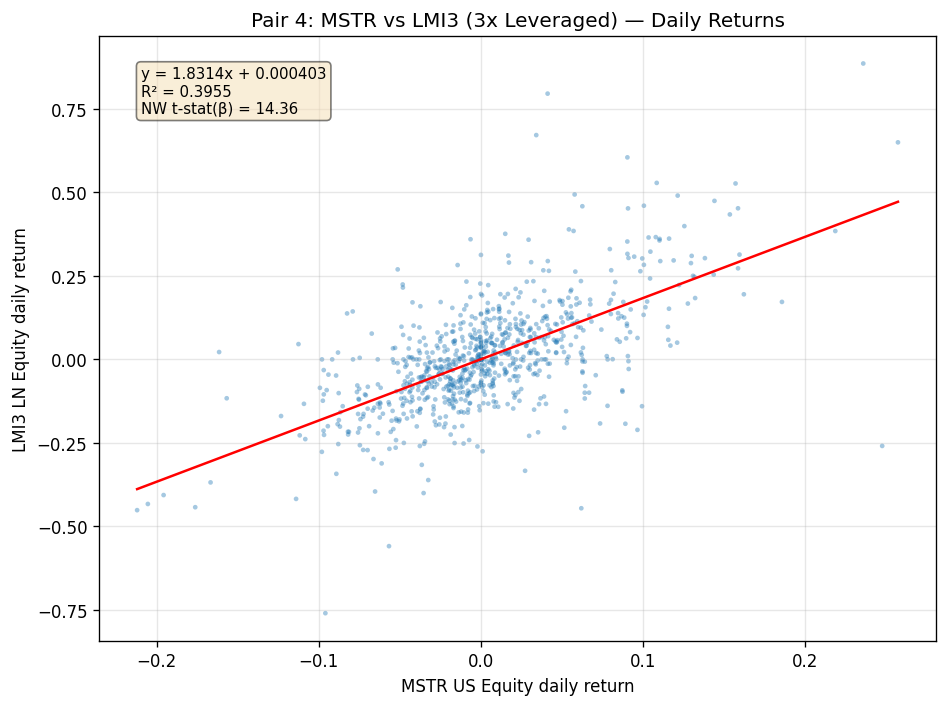

In [16]:
model4 = plot_pair_scatter(pair4, "MSTR US Equity", "LMI3 LN Equity",
                           "Pair 4: MSTR vs LMI3 (3x Leveraged) — Daily Returns")

In [17]:
print("Regression & Tracking Stats (NW standard errors):")
print("-" * 50)
row4 = print_pair_stats(pair4, "MSTR US Equity", "LMI3 LN Equity", model4)
summary_rows.append(row4)
print(f"\n  NOTE: Expected β ≈ 3.0 (3x daily leverage). Actual β = {model4.params[1]:.4f}")

Regression & Tracking Stats (NW standard errors):
--------------------------------------------------
Correlation:                   0.628901
Beta (slope):                  1.831431
Alpha (intercept):             0.00040344
R-squared:                     0.395516
NW Std Err (beta):             0.127535
NW t-stat (beta):              14.36
NW p-value (beta):             9.19e-47
Tracking error (std spread):   0.131902
Mean spread:                   0.00344281

  NOTE: Expected β ≈ 3.0 (3x daily leverage). Actual β = 1.8314


In [18]:
print("Outlier Detection (>3σ spread):")
print("-" * 50)
outliers4 = analyze_outliers(pair4, "MSTR US Equity", "LMI3 LN Equity")

Outlier Detection (>3σ spread):
--------------------------------------------------
  10 outlier(s) beyond 3.0σ (mean=0.003443, σ=0.131902):

    2024-08-05  spread=-0.6634  (-5.1σ)   [MSTR US Equity=-0.0960, LMI3 LN Equity=-0.7594]
    2024-11-22  spread=-0.5073  (-3.9σ)   [MSTR US Equity=+0.0619, LMI3 LN Equity=-0.4454]
    2025-04-09  spread=-0.5065  (-3.9σ)   [MSTR US Equity=+0.2476, LMI3 LN Equity=-0.2590]
    2024-03-19  spread=-0.5021  (-3.8σ)   [MSTR US Equity=-0.0567, LMI3 LN Equity=-0.5588]
    2024-03-13  spread=+0.4197  (+3.2σ)   [MSTR US Equity=+0.1085, LMI3 LN Equity=+0.5281]
    2025-12-02  spread=+0.4357  (+3.3σ)   [MSTR US Equity=+0.0578, LMI3 LN Equity=+0.4935]
    2023-02-02  spread=+0.5141  (+3.9σ)   [MSTR US Equity=+0.0904, LMI3 LN Equity=+0.6045]
    2024-03-21  spread=+0.6370  (+4.8σ)   [MSTR US Equity=+0.0341, LMI3 LN Equity=+0.6711]
    2024-03-04  spread=+0.6495  (+4.9σ)   [MSTR US Equity=+0.2359, LMI3 LN Equity=+0.8854]
    2024-03-11  spread=+0.7541  (+5.7σ) 

### Pair 4 Discussion

**How well do the returns track?**

Over **844** overlapping trading days (**Oct 2022–Dec 2025**), the OLS regression of **LMI3** daily returns on **MSTR** daily returns (Newey–West errors) gives **β ≈ 1.83**, **well below** the **≈3** one would expect if each day were a clean **3× daily** replication of MSTR. **R² ≈ 0.40** and **correlation ≈ 0.63**—both **far weaker** than the other pairs here (typically **R² > 0.95**). The **tracking error** (std of the spread) is about **0.132** in daily-return units, i.e. **order of magnitude larger** than the **single-digit–basis-point** tracking errors in the index/ETF pairs. The ETP is also **swap-based** and subject to **fees** and **rebalancing** that break a textbook **3×** mapping. Part of that is mechanical: **LMI3** trades on the **LSE** (about **8:00–16:30** London) and **MSTR** on **NASDAQ** (**9:30–16:00** New York), so **close-to-close** windows do not line up; 

**Notable outliers?**

**MSTR** is a volatile **Bitcoin** proxy; **LMI3** can print **extreme** daily returns when liquidity or **NAV/premium** moves matter. The largest **|spread|** days in the sample include **2024-03-11** (about **+5.7σ**), **2024-03-04** (**+4.9σ**), and **2024-03-21** (**+4.8σ**): **MSTR** moves **moderately** while **LMI3** moves **much more**, so the **3×** story is **unstable** day to day. **2024-08-05** (about **−5.1σ**) is a stark **breakdown**: **MSTR** ≈ **−9.6%** but **LMI3** ≈ **−75.9%**—far from **3×** on that day. **2025-04-09** (**−3.9σ**) shows **opposite signs** (**MSTR** ≈ **+24.8%**, **LMI3** ≈ **−25.9%**), which is impossible to reconcile with a **simple** linear **hedge** and underscores **ETP-specific** risk, not a tight **arbitrage** against the stock.

**Pairs trading opportunity?**

Data as from **Bloomberg** are recorded in **Section 0.5** (**LMI3** vs **MSTR** rows and optional **LMI3** fund subtable). **Illustrative snapshot:** **LMI3 LN** quoted **32.0 / 34.0 GBp** (**~33 GBp** mid), **~2 GBp** wide (**~6%** of mid **one-way**), **~945k** shares/day **90D** average aggregate volume and **~180k** shares **session** volume on the quote screen; **inside** depth **740k × 859k** shares. **MSTR US** (same table): **170.77 / 170.80** (**~0.018%** of mid), **~22M** shares and **~$3.68B** value that session—**deep** **NASDAQ** liquidity **vs** **LMI3** **London** **ETP**. The **economic** point is **asymmetric** frictions: **~6%** of mid **one-way** on **LMI3** **vs** **~0.02%** on **MSTR** (and **~0.004%** on **SPY** in **Section 0.5** for scale). Optional fund fields: **NAV ~USD 0.30**, **premium to NAV ~−11%**, **1Y return vs index ~−98.5%**, consistent with **3× daily** **swap** **path** and **costs**. **Volatility drag** and **non-overlapping** **LSE**/**US** **closes** break a clean **daily** hedge. Pair 4 is a **noisy statistical relationship**, not a risk-free convergence trade.


---
## Pair 5: WTI Oil Future vs. Spot Oil — CL1 Comdty vs. BCSL0090 Index

**Economic relationship:** **CL1 Comdty** is **Bloomberg’s generic 1st CL**—the **continuous front-month WTI crude oil** future (**NYMEX**); each listed month is **1,000 bbl** per contract, quoted **USD/bbl**, with **$1,000** dollars **PnL per $1.00/bbl** move, and the generic **rolls on expiration** onto the new front month. **BCSL0090** is a **spot** crude oil price index. By cost-of-carry for storable commodities,
futures ≈ spot × e^{(r + storage - convenience yield)T}. Returns should be closely related,
but the convenience yield and storage costs introduce more basis risk than financial futures.

**Key event:** In April 2020, WTI futures briefly traded negative (–$37.63) due to
storage capacity constraints at Cushing, OK. This is a critical outlier to examine.

In [19]:
print("=" * 60)
print("PAIR 5: CL1 Comdty vs BCSL0090 Index (WTI Future vs Spot Oil)")
print("=" * 60)
pair5 = prepare_pair("CL1 Comdty", "BCSL0090 Index")

PAIR 5: CL1 Comdty vs BCSL0090 Index (WTI Future vs Spot Oil)
  CL1 Comdty: 1827 price obs  |  BCSL0090 Index: 1827 price obs
  Matched trading days (after dropna): 1826
  Date range: 2019-01-02 to 2025-12-31


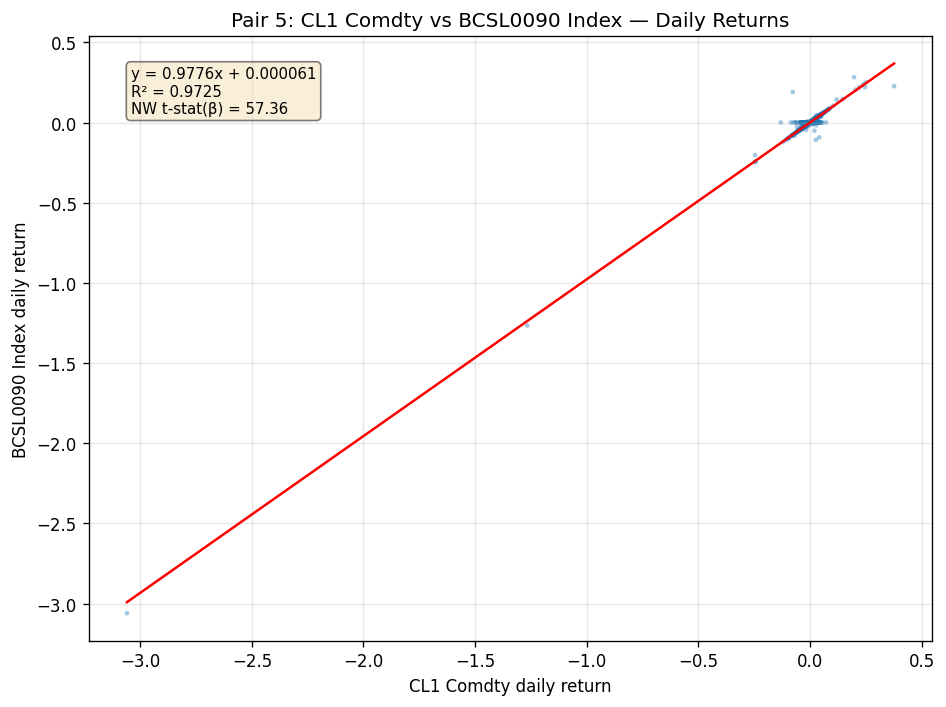

In [20]:
model5 = plot_pair_scatter(pair5, "CL1 Comdty", "BCSL0090 Index",
                           "Pair 5: CL1 Comdty vs BCSL0090 Index — Daily Returns")

In [21]:
print("Regression & Tracking Stats (NW standard errors):")
print("-" * 50)
row5 = print_pair_stats(pair5, "CL1 Comdty", "BCSL0090 Index", model5)
summary_rows.append(row5)

Regression & Tracking Stats (NW standard errors):
--------------------------------------------------
Correlation:                   0.986177
Beta (slope):                  0.977562
Alpha (intercept):             0.00006050
R-squared:                     0.972545
NW Std Err (beta):             0.017042
NW t-stat (beta):              57.36
NW p-value (beta):             0.00e+00
Tracking error (std spread):   0.013791
Mean spread:                   0.00009327


In [22]:
print("Outlier Detection (>3σ spread):")
print("-" * 50)
outliers5 = analyze_outliers(pair5, "CL1 Comdty", "BCSL0090 Index")

Outlier Detection (>3σ spread):
--------------------------------------------------
  28 outlier(s) beyond 3.0σ (mean=0.000093, σ=0.013791):

    2020-04-22  spread=-0.1499  (-10.9σ)   [CL1 Comdty=+0.3766, BCSL0090 Index=+0.2268]
    2021-11-29  spread=-0.1341  (-9.7σ)   [CL1 Comdty=+0.0264, BCSL0090 Index=-0.1077]
    2020-03-23  spread=-0.1337  (-9.7σ)   [CL1 Comdty=+0.0415, BCSL0090 Index=-0.0923]
    2025-06-13  spread=-0.0726  (-5.3σ)   [CL1 Comdty=+0.0726, BCSL0090 Index=+0.0000]
    2020-03-25  spread=-0.0710  (-5.2σ)   [CL1 Comdty=+0.0200, BCSL0090 Index=-0.0510]
    2025-10-23  spread=-0.0562  (-4.1σ)   [CL1 Comdty=+0.0562, BCSL0090 Index=+0.0000]
    2024-10-03  spread=-0.0515  (-3.7σ)   [CL1 Comdty=+0.0515, BCSL0090 Index=+0.0000]
    2025-06-11  spread=-0.0488  (-3.5σ)   [CL1 Comdty=+0.0488, BCSL0090 Index=+0.0000]
    2025-04-09  spread=-0.0465  (-3.4σ)   [CL1 Comdty=+0.0465, BCSL0090 Index=+0.0000]
    2020-03-24  spread=-0.0450  (-3.3σ)   [CL1 Comdty=+0.0278, BCSL0090 Ind

### Pair 5 Discussion

**How well do the returns track?**

Daily returns are highly correlated: correlation approximately 0.986, beta approximately 0.978, and R-squared approximately 0.973. That is broadly in line with Pair 1 (ES vs. SPX) and slightly below Pair 2 (SPY vs. SPX), which makes sense for two series tied to WTI. However, the tracking error (standard deviation of the spread) is about 138 basis points — much larger than the equity and gold pairs (roughly 8–28 bps in Pairs 1–3). That extra noise reflects commodity basis risk: storage, insurance, and the convenience yield link spot and futures prices in ways that pure financial cost-of-carry alone does not pin down as tightly as for index futures or ETFs.

**Notable outliers?**

There are 28 outliers beyond 3 standard deviations. The largest is March 26, 2020 (+19.4σ), when spot (BCSL0090) moved much more than the front-month future on a single day — a huge basis shock in the early COVID period. Other extremes cluster in the same window: March 23–25, 2020; April 22–23 and April 27, 2020. That April 2020 episode is the WTI crash and extremely stressed Cushing storage; front-month futures traded at unprecedented levels (including negative prints on some contracts around April 20, 2020), while the spot index can record large percentage moves with different timing and convention, so the spread blows out even if a particular calendar date is not always the top row in this table. November 26–29, 2021 shows very large spreads (Thanksgiving week: US oil futures often move while the spot index can be stale or zero on holidays). Many 2024–2025 outliers show BCSL0090 at exactly 0% while CL1 moved — likely stale or non-updated spot index prints on certain sessions — which mechanically widens the spread without implying a new economic shock.

**Pairs trading opportunity?**

The futures–spot basis in oil is well studied and is not a risk-free arbitrage. To exploit a perceived mispricing you must take or offset physical delivery at Cushing, lease storage, or bear inventory risk. The basis can sit in sustained contango or backwardation because commodity markets price storage costs and convenience yield; a wide spread is often compensation for bearing those risks, not a free lunch. Over long horizons the basis tends to be mean-reverting after shocks, but trading it requires capital, margin, and tolerance for the same fundamentals that drive the basis (inventory, OPEC, geopolitics). In that sense this pair is closer to **statistical pairs trading** on a risky basis than to **true arbitrage**; any apparent edge must clear bid-ask spreads, roll costs, and the possibility that the spread widens further before it converges.

**Transaction costs (Bloomberg):** See **Section 0.5**, **CL1 Comdty** row for **futures** **bid–ask**; **snapshot** **notes** add **session** **volume** and **open** **interest**. **BCSL0090** is an **index**, not a **direct** **execution** **price**; **spot** **oil** **exposure** **in** **practice** uses **physical**, **storage**, or **other** **instruments**, each with **its** **own** **spread** **and** **risk**. **Any** **basis** **trade** **must** **clear** **the** **CL1** **frictions** **in** **the** **table** **plus** **roll**, **margin**, and **inventory**/**convenience** **yield** **risk**—not **pure** **arbitrage**.
